In [1]:
# imports
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

In [2]:
# loading the model
class MLPExperiment(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 2),
        )

    def forward(self, x):

        return self.network(x)

In [3]:
model = MLPExperiment()

model.load_state_dict(
    torch.load("/Users/admin/Desktop/reliable_rejection_under_degradation/ablation_study/saved_models/A4_quality_margin_model.pth", map_location=torch.device("cpu"))
)

model.eval()

print("MLP Loaded")

MLP Loaded


In [4]:
# loading the scaler
scaler = joblib.load("/Users/admin/Desktop/reliable_rejection_under_degradation/ablation_study/saved_scalers/A4_quality_margin_scaler.pkl")

print("Scaler Loaded")

Scaler Loaded


In [5]:
# loading datasets
datasets = {
    "Degraded": "/Users/admin/Desktop/reliable_rejection_under_degradation/ablation_study/degraded_mlp.csv",
    "Clean": "/Users/admin/Desktop/reliable_rejection_under_degradation/ablation_study/clean_mlp.csv",
    "Natural": "/Users/admin/Desktop/reliable_rejection_under_degradation/ablation_study/natural_mlp.csv",
    "Unknown": "/Users/admin/Desktop/reliable_rejection_under_degradation/ablation_study/unknown_mlp.csv",
}

In [6]:
# evaluation function
def evaluate_dataset(csv_file):

    df = pd.read_csv(csv_file)

    X = df[["quality_score", "margin"]]

    y_true = df["label"]

    X_scaled = scaler.transform(X)

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

    with torch.no_grad():

        outputs = model(X_tensor)

        y_pred = torch.argmax(outputs, dim=1).numpy()

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred, zero_division=0)

    recall = recall_score(y_true, y_pred, zero_division=0)

    f1 = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2, 2):

        TN, FP, FN, TP = cm.ravel()

        TAR = TP / (TP + FN) if (TP + FN) > 0 else np.nan

        FRR = FN / (TP + FN) if (TP + FN) > 0 else np.nan

        TRR = TN / (TN + FP) if (TN + FP) > 0 else np.nan

        FAR = FP / (TN + FP) if (TN + FP) > 0 else np.nan

    else:

        TAR = np.nan
        FRR = np.nan
        TRR = np.nan
        FAR = np.nan

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TAR": TAR,
        "FRR": FRR,
        "TRR": TRR,
        "FAR": FAR,
        "y_true": y_true,
        "y_pred": y_pred,
    }

In [7]:
# threshold evaluation
def evaluate_threshold(csv_file):

    df = pd.read_csv(csv_file)

    y_true = df["label"]

    threshold_pred = (df["best_similarity"] >= 0.6).astype(int)

    accuracy = accuracy_score(y_true, threshold_pred)

    precision = precision_score(y_true, threshold_pred, zero_division=0)

    recall = recall_score(y_true, threshold_pred, zero_division=0)

    f1 = f1_score(y_true, threshold_pred, zero_division=0)

    cm = confusion_matrix(y_true, threshold_pred)

    if cm.shape == (2, 2):

        TN, FP, FN, TP = cm.ravel()

        TAR = TP / (TP + FN) if (TP + FN) > 0 else np.nan

        FRR = FN / (TP + FN) if (TP + FN) > 0 else np.nan

        TRR = TN / (TN + FP) if (TN + FP) > 0 else np.nan

        FAR = FP / (TN + FP) if (TN + FP) > 0 else np.nan

    else:

        TAR = np.nan
        FRR = np.nan
        TRR = np.nan
        FAR = np.nan

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TAR": TAR,
        "FRR": FRR,
        "TRR": TRR,
        "FAR": FAR,
        "y_true": y_true,
        "y_pred": threshold_pred,
    }

In [8]:
# running our multi layer MLP
A4_results = {}

for dataset_name, csv_file in datasets.items():

    result = evaluate_dataset(csv_file)

    A4_results[dataset_name] = result

    print("\n======================")
    print(dataset_name)
    print("======================")

    print(pd.DataFrame([result]).round(4))


Degraded
   Accuracy  Precision  Recall      F1     TAR     FRR     TRR     FAR  \
0    0.9648     0.9961  0.9678  0.9817  0.9678  0.0322  0.8333  0.1667   

                                              y_true  \
0  0      1
1      1
2      1
3      1
4      1
 ...   

                                              y_pred  
0  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...  

Clean
   Accuracy  Precision  Recall      F1     TAR     FRR     TRR     FAR  \
0     0.963     0.9922  0.9697  0.9808  0.9697  0.0303  0.6667  0.3333   

                                              y_true  \
0  0      1
1      1
2      1
3      1
4      1
 ...   

                                              y_pred  
0  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...  

Natural
   Accuracy  Precision  Recall     F1     TAR     FRR  TRR  FAR  \
0    0.7415        1.0  0.7286  0.843  0.7286  0.2714  1.0  0.0   

                                              y_true  \
0  0      1
1      1
2      1
3      1


/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [9]:
# running fixed threshold method
threshold_results = {}

for dataset_name, csv_file in datasets.items():

    result = evaluate_threshold(csv_file)

    threshold_results[dataset_name] = result

    print("\n======================")
    print(dataset_name)
    print("======================")

    print(pd.DataFrame([result]).round(4))


Degraded
   Accuracy  Precision  Recall      F1     TAR     FRR  TRR  FAR  \
0    0.6037        1.0  0.5947  0.7458  0.5947  0.4053  1.0  0.0   

                                              y_true  \
0  0      1
1      1
2      1
3      1
4      1
 ...   

                                              y_pred  
0  0      1
1      0
2      0
3      0
4      1
 ...  

Clean
   Accuracy  Precision  Recall      F1     TAR     FRR  TRR  FAR  \
0    0.7333        1.0  0.7273  0.8421  0.7273  0.2727  1.0  0.0   

                                              y_true  \
0  0      1
1      1
2      1
3      1
4      1
 ...   

                                              y_pred  
0  0      0
1      1
2      1
3      0
4      1
 ...  

Natural
   Accuracy  Precision  Recall      F1    TAR    FRR  TRR  FAR  \
0     0.119        1.0   0.075  0.1395  0.075  0.925  1.0  0.0   

                                              y_true  \
0  0      1
1      1
2      1
3      1
4      1
 ...   

        

/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [10]:
# final master comparison table
master_rows = []

for dataset_name in datasets.keys():

    for method_name, result_dict in [
        ("Threshold", threshold_results[dataset_name]),
        ("A4: Quality and Margin", A4_results[dataset_name]),
    ]:

        row = {"Dataset": dataset_name, "Method": method_name}

        row.update(result_dict)

        master_rows.append(row)

master_table = pd.DataFrame(master_rows)

master_table = master_table.round(4)
display(master_table)

,Dataset,Method,Accuracy,Precision,Recall,F1,TAR,FRR,TRR,FAR,y_true,y_pred
0,Degraded,Threshold,0.6037,1.0000,0.5947,0.7458,0.5947,0.4053,1.0000,0.0000,0 1 1 1 2 1 3 1 4 1 ...,0 1 1 0 2 0 3 0 4 1 ...
1,Degraded,A4: Quality and Margin,0.9648,0.9961,0.9678,0.9817,0.9678,0.0322,0.8333,0.1667,0 1 1 1 2 1 3 1 4 1 ...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,Clean,Threshold,0.7333,1.0000,0.7273,0.8421,0.7273,0.2727,1.0000,0.0000,0 1 1 1 2 1 3 1 4 1 ...,0 0 1 1 2 1 3 0 4 1 ...
3,Clean,A4: Quality and Margin,0.9630,0.9922,0.9697,0.9808,0.9697,0.0303,0.6667,0.3333,0 1 1 1 2 1 3 1 4 1 ...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,Natural,Threshold,0.1190,1.0000,0.0750,0.1395,0.0750,0.9250,1.0000,0.0000,0 1 1 1 2 1 3 1 4 1 ...,0 0 1 0 2 0 3 0 4 0 ...
5,Natural,A4: Quality and Margin,0.7415,1.0000,0.7286,0.8430,0.7286,0.2714,1.0000,0.0000,0 1 1 1 2 1 3 1 4 1 ...,"[0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, ..."
6,Unknown,Threshold,1.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,0 0 1 0 2 0 3 0 4 0 ...,0 0 1 0 2 0 3 0 4 0 ...
7,Unknown,A4: Quality and Margin,1.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,0 0 1 0 2 0 3 0 4 0 ...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [11]:
FIGURES_DIR= "/Users/admin/Desktop/reliable_rejection_under_degradation/ablation_study/ablation_study_figures/A4_QualiMarg"

In [12]:
# confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def save_confusion_matrix(
    y_true,
    y_pred,
    title,
    filename
):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Reject", "Accept"],
        yticklabels=["Reject", "Accept"]
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)

    plt.tight_layout()

    plt.savefig(
        f"{FIGURES_DIR}/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

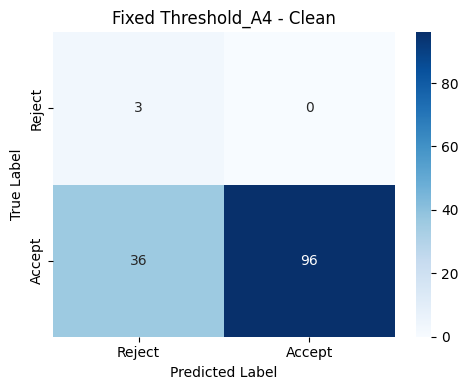

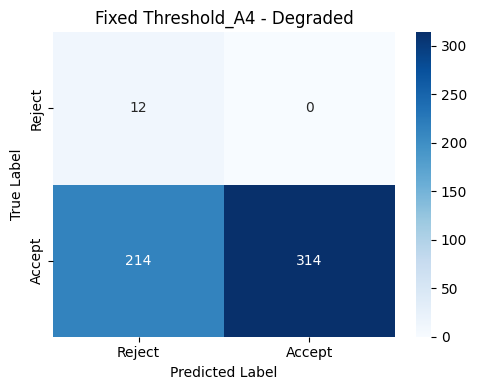

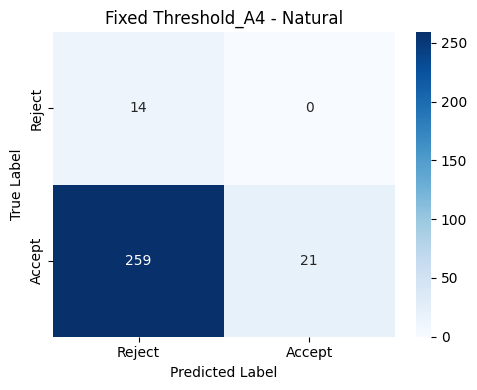

In [13]:
#threshold confusion matrices
for dataset_name in [
    "Clean",
    "Degraded",
    "Natural"
]:

    save_confusion_matrix(
        threshold_results[dataset_name]["y_true"],
        threshold_results[dataset_name]["y_pred"],
        f"Fixed Threshold_A4 - {dataset_name}",
        f"threshold_A4_{dataset_name.lower()}_cm.png"
    )

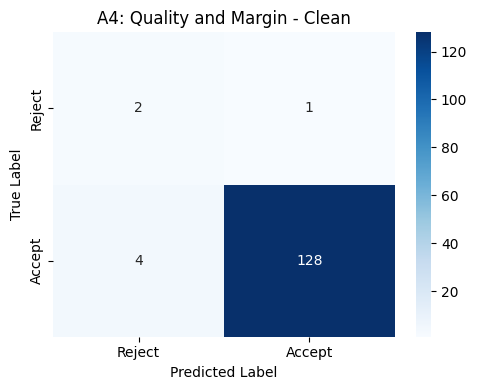

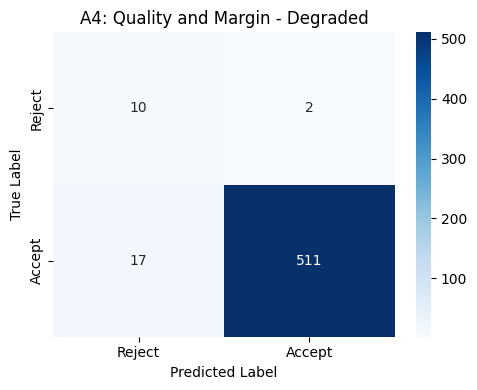

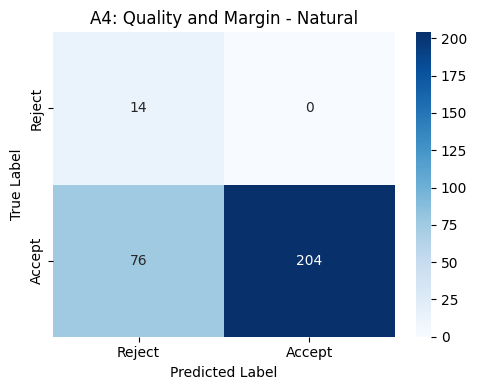

In [14]:
# mlp confusion matrices
for dataset_name in [
    "Clean",
    "Degraded",
    "Natural"
]:

    save_confusion_matrix(
        A4_results[dataset_name]["y_true"],
        A4_results[dataset_name]["y_pred"],
        f"A4: Quality and Margin - {dataset_name}",
        f"mlp_A4_{dataset_name.lower()}_cm.png"
    )